<a href="https://colab.research.google.com/github/Okwy1991/A-comic-picture-message/blob/main/clustering_algorithm_for_Bayesian_Gaussian%C2%A0Mixture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Colab's content directory.jpeg to Colab's content directory.jpeg


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


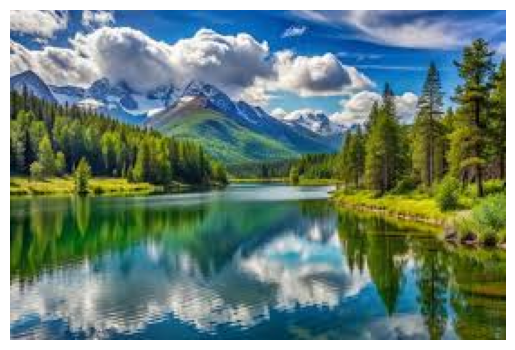

In [5]:
image_path = list(uploaded.keys())[0]  # Get the uploaded file name
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()


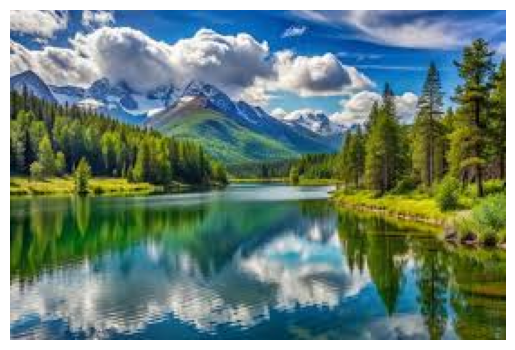

In [6]:
image_path = list(uploaded.keys())[0]
plt.imshow(img)
plt.axis('off')
plt.show()


In [11]:
img_array = np.array(img)
print(f"Image shape: {img_array.shape}")
reshaped_img = img_array.reshape(-1, 3)  # Reshape to (num_pixels, num_channels)
print(f"Reshaped image shape: {reshaped_img.shape}")
reshaped_img = reshaped_img / 255.0  # Scale pixel values to [0, 1]
!pip install scikit-learn


Image shape: (183, 275, 3)
Reshaped image shape: (50325, 3)


In [12]:
from sklearn.mixture import BayesianGaussianMixture #Fit the Bayesian Gaussian Mixture Mode

bgmm = BayesianGaussianMixture(n_components=5, random_state=42)
labels = bgmm.fit_predict(reshaped_img)
print(f"Number of components: {len(set(labels))}")


Number of components: 5


/usr/local/lib/python3.10/dist-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


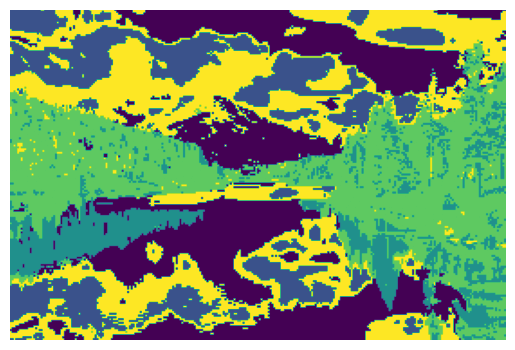

In [13]:
clustered_img = labels.reshape(img_array.shape[:2])#Visualize the Clustering
plt.imshow(clustered_img, cmap='viridis')
plt.axis('off')
plt.show()


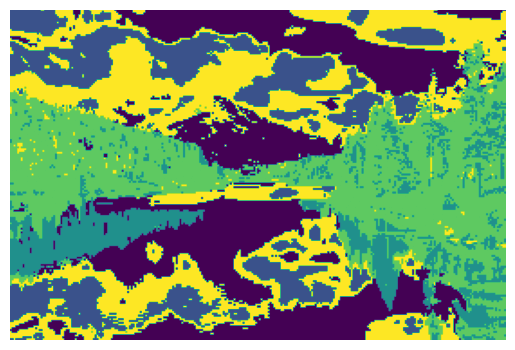

In [14]:
clustered_img = labels.reshape(img_array.shape[:2])#Reshape the labels back to the original image shape
plt.imshow(clustered_img, cmap='viridis')
plt.axis('off')
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage import io

In [16]:

image_path = "Colab's content directory.jpeg"
image = io.imread(image_path)


if image.shape[2] == 4:
    image = image[:, :, :3]


pixels = image.reshape(-1, 3)


n_clusters = 3

In [17]:
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(pixels)

GaussianMixture(n_components=3, random_state=42)

In [18]:
labels = gmm.predict(pixels)


segmented_image = labels.reshape(image.shape[:2])

In [19]:
labels

array([1, 1, 1, ..., 2, 2, 2])

In [20]:
prob_pix = gmm.predict_proba(pixels)
prob_pix

array([[3.59968567e-04, 9.99640031e-01, 2.10185760e-16],
       [2.38109621e-04, 9.99761890e-01, 4.43066421e-17],
       [1.09896318e-03, 9.98901037e-01, 2.29411281e-14],
       ...,
       [5.07744105e-02, 8.97312402e-12, 9.49225589e-01],
       [3.38313631e-02, 3.98996843e-13, 9.66168637e-01],
       [2.79757218e-02, 2.20425978e-13, 9.72024278e-01]])

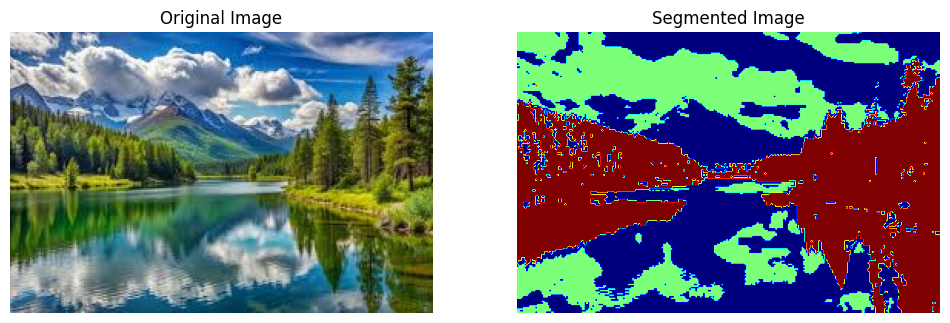

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='jet')
plt.title('Segmented Image')
plt.axis('off')

plt.show()